# 🏦 STAGE 2: CIBIL DEEP DIVE MODEL TRAINING

**Purpose:** Train Random Forest model on External CIBIL Dataset (62 features)

**Target:** P1 / P2 / P3 / P4 (Risk Tiers)

**Dataset:** 51,336 records from Indian Bank CIBIL data

**Author:** Zen Meraki

**Date:** February 2026

---

## 📋 Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Load Data](#2-load-data)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Data Cleaning](#4-data-cleaning)
5. [Feature Engineering](#5-feature-engineering)
6. [Feature Selection](#6-feature-selection)
7. [Model Training](#7-model-training)
8. [Model Evaluation](#8-model-evaluation)
9. [Feature Importance Analysis](#9-feature-importance)
10. [Save Model](#10-save-model)
11. [Test Predictions](#11-test-predictions)

---
## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve
)

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    mutual_info_classif,
    RFE
)

# Model persistence
import joblib

# Utilities
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")
print(f"📅 Training started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Libraries imported successfully!
📅 Training started: 2026-02-11 11:59:05


---
## 2. Load Data

In [2]:
# Load CIBIL dataset
print("📊 Loading CIBIL dataset...")

# Update this path to your file location
DATASET_PATH = r'C:\Users\user\OneDrive\Documents\CREDIT_RISK_ENGINE\DATA\processed\External_Cibil_Dataset.xlsx'

df = pd.read_excel(DATASET_PATH)

print(f"✅ Loaded: {len(df):,} records × {len(df.columns)} columns")
print(f"\n📋 Dataset shape: {df.shape}")
print(f"\n📋 First 5 rows:")
df.head()

📊 Loading CIBIL dataset...
✅ Loaded: 51,336 records × 62 columns

📋 Dataset shape: (51336, 62)

📋 First 5 rows:


,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_utilization,CC_Flag,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,549,35,15,11,29,29,0,0,0,-99999,-99999,0,0,21,5,11,0,0,0,0,0,0,0,0,0,29,6,0,0,0,6,0,0,566,0,0,0,Married,12TH,48,M,51000,114,0.200,0.0,0.798,-99999.0,0,0.798,1,0.0,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,47,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,209,1,0,0,Single,GRADUATE,23,F,19000,50,1.000,0.0,0.370,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,302,11,3,9,25,25,1,9,8,25,25,0,0,10,5,10,0,0,0,0,0,0,0,0,0,25,4,0,0,0,0,0,0,587,0,0,0,Married,SSC,40,M,18,191,1.000,0.5,0.585,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,-99999,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,5,4,5,0,0,0,0,0,0,0,0,0,0,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,Married,SSC,34,M,10000,246,1.000,1.0,0.990,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,583,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,53,4,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,3951,0,0,0,Married,POST-GRADUATE,48,M,15000,75,0.333,0.0,0.000,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


In [3]:
# Column overview
print("📋 All Columns:")
print("=" * 80)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

📋 All Columns:
 1. PROSPECTID
 2. time_since_recent_payment
 3. time_since_first_deliquency
 4. time_since_recent_deliquency
 5. num_times_delinquent
 6. max_delinquency_level
 7. max_recent_level_of_deliq
 8. num_deliq_6mts
 9. num_deliq_12mts
10. num_deliq_6_12mts
11. max_deliq_6mts
12. max_deliq_12mts
13. num_times_30p_dpd
14. num_times_60p_dpd
15. num_std
16. num_std_6mts
17. num_std_12mts
18. num_sub
19. num_sub_6mts
20. num_sub_12mts
21. num_dbt
22. num_dbt_6mts
23. num_dbt_12mts
24. num_lss
25. num_lss_6mts
26. num_lss_12mts
27. recent_level_of_deliq
28. tot_enq
29. CC_enq
30. CC_enq_L6m
31. CC_enq_L12m
32. PL_enq
33. PL_enq_L6m
34. PL_enq_L12m
35. time_since_recent_enq
36. enq_L12m
37. enq_L6m
38. enq_L3m
39. MARITALSTATUS
40. EDUCATION
41. AGE
42. GENDER
43. NETMONTHLYINCOME
44. Time_With_Curr_Empr
45. pct_of_active_TLs_ever
46. pct_opened_TLs_L6m_of_L12m
47. pct_currentBal_all_TL
48. CC_utilization
49. CC_Flag
50. PL_utilization
51. PL_Flag
52. pct_PL_enq_L6m_of_L12m
53. pct_

---
## 3. Exploratory Data Analysis (EDA)

In [4]:
# Basic statistics
print("📊 Dataset Info:")
df.info()

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 62 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROSPECTID                    51336 non-null  int64  
 1   time_since_recent_payment     51336 non-null  int64  
 2   time_since_first_deliquency   51336 non-null  int64  
 3   time_since_recent_deliquency  51336 non-null  int64  
 4   num_times_delinquent          51336 non-null  int64  
 5   max_delinquency_level         51336 non-null  int64  
 6   max_recent_level_of_deliq     51336 non-null  int64  
 7   num_deliq_6mts                51336 non-null  int64  
 8   num_deliq_12mts               51336 non-null  int64  
 9   num_deliq_6_12mts             51336 non-null  int64  
 10  max_deliq_6mts                51336 non-null  int64  
 11  max_deliq_12mts               51336 non-null  int64  
 12  num_times_30p_dpd             51336 non-null

In [5]:
# Statistical summary
print("📊 Statistical Summary:")
df.describe()

📊 Statistical Summary:


,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,AGE,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_utilization,CC_Flag,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,Credit_Score
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,5.133600e+04,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25668.500000,-8129.961314,-70020.091320,-70022.375838,1.573749,-70003.987085,13.521953,0.184977,0.480053,0.295076,-25105.208587,-21092.727676,0.728884,0.426971,9.204671,1.484027,3.319444,0.062646,0.002435,0.009292,0.025947,0.001208,0.004130,0.015097,0.000974,0.002844,11.266090,-12308.234046,-12312.463866,-12312.734261,-12312.644869,-12311.878195,-12312.429270,-12312.209229,-12084.842099,-12310.233248,-12311.123987,-12311.784771,33.758532,2.642419e+04,110.707846,0.577542,0.302955,-139.416072,-92791.608990,0.089469,-86556.225194,0.167874,0.190414,0.065182,0.170492,0.056302,-45127.943635,0.271116,0.052887,679.859222
std,14819.571046,27749.328514,45823.312757,45819.820741,4.165012,45847.976100,53.336976,0.710240,1.522210,1.027471,43366.162767,40805.742595,2.762120,2.101404,21.308881,3.364581,7.518414,0.801218,0.091383,0.233403,0.635611,0.070331,0.179885,0.529730,0.075413,0.185349,46.100309,32860.363869,32858.778356,32858.677000,32858.710505,32858.997860,32858.791308,32858.873781,32946.916037,32859.614436,32859.280542,32859.032853,8.816364,2.002711e+04,76.046831,0.379867,0.406049,3742.613530,25861.225129,0.285423,34111.414750,0.373758,0.376218,0.235706,0.350209,0.213506,49795.784556,0.444540,0.223810,20.502764
min,1.000000,-99999.000000,-99999.000000,-99999.000000,0.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,-99999.000000,-99999.000000,-99999.000000,-99999.000000,-99999.000000,-99999.000000,-99999.000000,-99999.000000,-99999.000000,-99999.000000,21.000000,0.000000e+00,0.000000,0.000000,0.000000,-99999.000000,-99999.000000,0.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,469.000000
25%,12834.750000,46.000000,-99999.000000,-99999.000000,0.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,27.000000,1.800000e+04,61.000000,0.250000,0.000000,0.083000,-99999.000000,0.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,669.00000

🎯 Target Variable: Approved_Flag

Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64

Percentage Distribution:
Approved_Flag
P2    62.722066
P3    14.516129
P4    11.457846
P1    11.303958
Name: proportion, dtype: float64


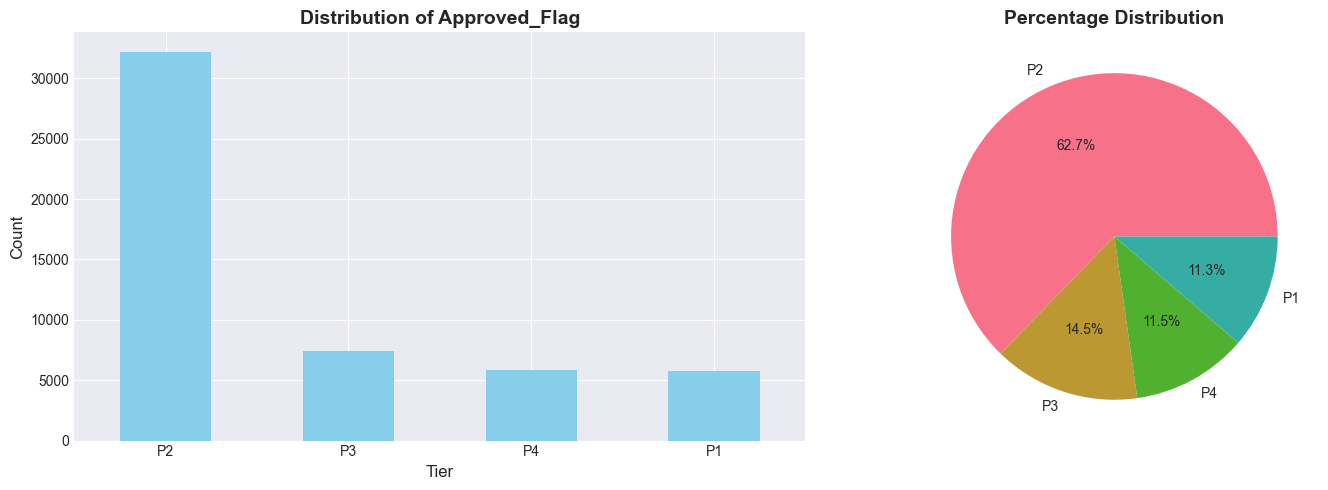


✅ Observation: Dataset is imbalanced with P2 being majority class (62.7%)


In [6]:
# Target variable distribution
print("🎯 Target Variable: Approved_Flag\n")
print(df['Approved_Flag'].value_counts())
print("\nPercentage Distribution:")
print(df['Approved_Flag'].value_counts(normalize=True) * 100)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Count plot
df['Approved_Flag'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Approved_Flag', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tier', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['Approved_Flag'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Percentage Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n✅ Observation: Dataset is imbalanced with P2 being majority class (62.7%)")

In [7]:
# Missing values analysis
print("🔍 Missing Values Analysis:\n")

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
}).sort_values('Missing_Count', ascending=False)

missing_df = missing_df[missing_df['Missing_Count'] > 0]

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
    
    # Visualize
    plt.figure(figsize=(12, 6))
    plt.barh(missing_df['Column'][:20], missing_df['Missing_Percentage'][:20])
    plt.xlabel('Missing Percentage (%)', fontsize=12)
    plt.title('Top 20 Columns with Missing Values', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values found!")

🔍 Missing Values Analysis:

✅ No missing values found!


In [8]:
# Data types distribution
print("📊 Data Types Distribution:\n")
print(df.dtypes.value_counts())

# Numerical vs Categorical
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n📊 Numerical columns: {len(numerical_cols)}")
print(f"📊 Categorical columns: {len(categorical_cols)}")

print(f"\nCategorical columns: {categorical_cols}")

📊 Data Types Distribution:

int64      46
float64    10
object      6
Name: count, dtype: int64

📊 Numerical columns: 56
📊 Categorical columns: 6

Categorical columns: ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2', 'Approved_Flag']


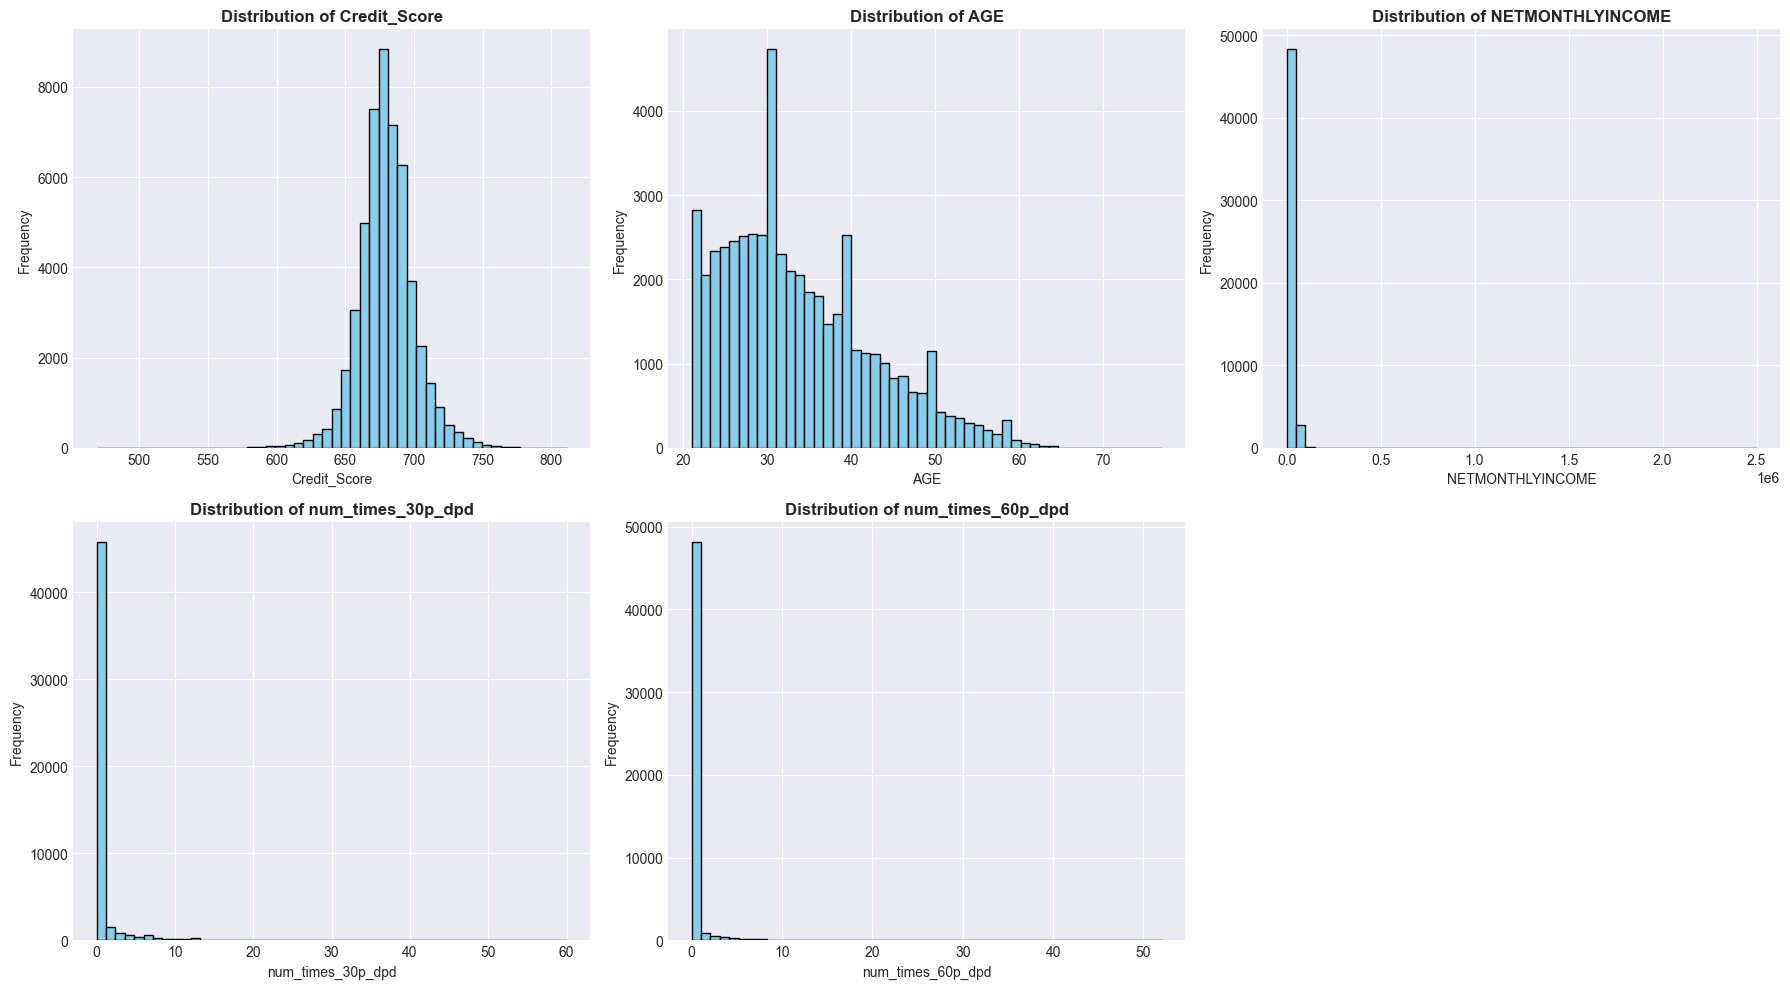

In [9]:
# Key feature distributions
key_features = ['Credit_Score', 'AGE', 'NETMONTHLYINCOME', 'num_times_30p_dpd', 'num_times_60p_dpd']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    if col in df.columns:
        df[col].hist(bins=50, ax=axes[i], color='skyblue', edgecolor='black')
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('Frequency', fontsize=10)

# Hide extra subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

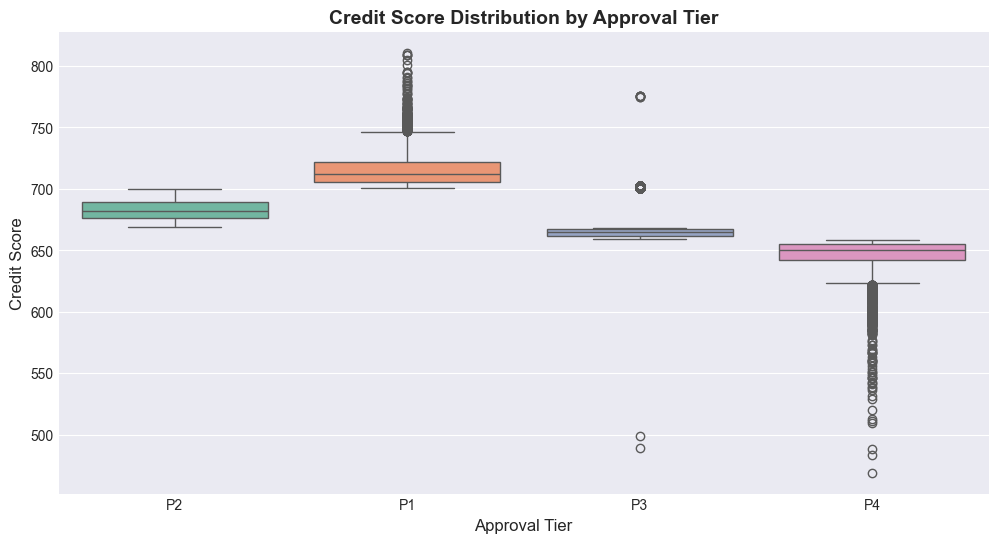


📊 Credit Score by Tier:
                 count        mean        std    min    25%    50%    75%  \
Approved_Flag                                                               
P1              5803.0  715.952266  13.485114  701.0  706.0  712.0  722.0   
P2             32199.0  682.584614   8.331576  669.0  676.0  682.0  689.0   
P3              7452.0  666.995035  11.301156  489.0  662.0  665.0  667.0   
P4              5882.0  645.629548  15.505251  469.0  642.0  650.0  655.0   

                 max  
Approved_Flag         
P1             811.0  
P2             700.0  
P3             776.0  
P4             658.0  


In [10]:
# Credit Score by Approved_Flag
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Approved_Flag', y='Credit_Score', palette='Set2')
plt.title('Credit Score Distribution by Approval Tier', fontsize=14, fontweight='bold')
plt.xlabel('Approval Tier', fontsize=12)
plt.ylabel('Credit Score', fontsize=12)
plt.show()

print("\n📊 Credit Score by Tier:")
print(df.groupby('Approved_Flag')['Credit_Score'].describe())

---
## 4. Data Cleaning

In [11]:
print("🧹 Cleaning data...\n")

# Create a copy
df_clean = df.copy()

# Fill missing values
for col in df_clean.columns:
    if df_clean[col].dtype in ['float64', 'int64']:
        df_clean[col] = df_clean[col].fillna(0)
    else:
        df_clean[col] = df_clean[col].fillna('Unknown')

# Check for duplicates
duplicates = df_clean.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"✅ Removed {duplicates} duplicate rows")

# Remove PROSPECTID (not a feature)
if 'PROSPECTID' in df_clean.columns:
    df_clean = df_clean.drop('PROSPECTID', axis=1)
    print("✅ Removed PROSPECTID column")

print(f"\n✅ Cleaned dataset shape: {df_clean.shape}")
print(f"✅ Missing values after cleaning: {df_clean.isnull().sum().sum()}")

🧹 Cleaning data...

Duplicate rows: 0
✅ Removed PROSPECTID column

✅ Cleaned dataset shape: (51336, 61)
✅ Missing values after cleaning: 0


---
## 5. Feature Engineering

In [12]:
print("🔧 Engineering new features...\n")

# 1. Delinquency Severity Score (0-100)
if 'max_delinquency_level' in df_clean.columns:
    df_clean['delinq_severity_score'] = (df_clean['max_delinquency_level'] / 3).clip(0, 100)
    print("✅ Created: delinq_severity_score")

# 2. High DPD Risk Flag
if 'num_times_30p_dpd' in df_clean.columns and 'num_times_60p_dpd' in df_clean.columns:
    df_clean['high_dpd_risk'] = (
        (df_clean['num_times_30p_dpd'] > 2) | 
        (df_clean['num_times_60p_dpd'] > 0)
    ).astype(int)
    print("✅ Created: high_dpd_risk")

# 3. Recent Delinquency Flag
if 'num_deliq_6mts' in df_clean.columns:
    df_clean['recent_deliq_flag'] = (df_clean['num_deliq_6mts'] > 0).astype(int)
    print("✅ Created: recent_deliq_flag")

# 4. Credit Hungry Flag
if 'enq_L3m' in df_clean.columns:
    df_clean['credit_hungry'] = (df_clean['enq_L3m'] > 3).astype(int)
    print("✅ Created: credit_hungry")

# 5. Account Quality Score
account_cols = ['num_std', 'num_sub', 'num_dbt', 'num_lss']
if all(col in df_clean.columns for col in account_cols):
    df_clean['account_quality_score'] = (
        df_clean['num_std'] * 10 +      # Standard = +10
        df_clean['num_sub'] * -5 +      # Sub-standard = -5
        df_clean['num_dbt'] * -15 +     # Doubtful = -15
        df_clean['num_lss'] * -25       # Loss = -25
    )
    print("✅ Created: account_quality_score")

# 6. High Utilization Flag
if 'pct_currentBal_all_TL' in df_clean.columns:
    df_clean['high_util_flag'] = (df_clean['pct_currentBal_all_TL'] > 0.75).astype(int)
    print("✅ Created: high_util_flag")

# 7. Employment Stability
if 'Time_With_Curr_Empr' in df_clean.columns:
    df_clean['employment_stable'] = (df_clean['Time_With_Curr_Empr'] >= 24).astype(int)
    print("✅ Created: employment_stable")

# 8. Total Delinquency Count
if 'num_times_30p_dpd' in df_clean.columns and 'num_times_60p_dpd' in df_clean.columns:
    df_clean['total_dpd_count'] = df_clean['num_times_30p_dpd'] + df_clean['num_times_60p_dpd']
    print("✅ Created: total_dpd_count")

# 9. Credit Activity Score (inquiries)
if 'enq_L3m' in df_clean.columns and 'enq_L6m' in df_clean.columns:
    df_clean['credit_activity_score'] = df_clean['enq_L3m'] + df_clean['enq_L6m'] * 0.5
    print("✅ Created: credit_activity_score")

# 10. Income to Delinquency Ratio
if 'NETMONTHLYINCOME' in df_clean.columns and 'num_times_delinquent' in df_clean.columns:
    df_clean['income_deliq_ratio'] = np.where(
        df_clean['num_times_delinquent'] > 0,
        df_clean['NETMONTHLYINCOME'] / (df_clean['num_times_delinquent'] + 1),
        df_clean['NETMONTHLYINCOME']
    )
    print("✅ Created: income_deliq_ratio")

print(f"\n✅ Total features after engineering: {len(df_clean.columns)}")
print(f"✅ New features added: {len(df_clean.columns) - len(df.columns)}")

🔧 Engineering new features...

✅ Created: delinq_severity_score
✅ Created: high_dpd_risk
✅ Created: recent_deliq_flag
✅ Created: credit_hungry
✅ Created: account_quality_score
✅ Created: high_util_flag
✅ Created: employment_stable
✅ Created: total_dpd_count
✅ Created: credit_activity_score
✅ Created: income_deliq_ratio

✅ Total features after engineering: 71
✅ New features added: 9


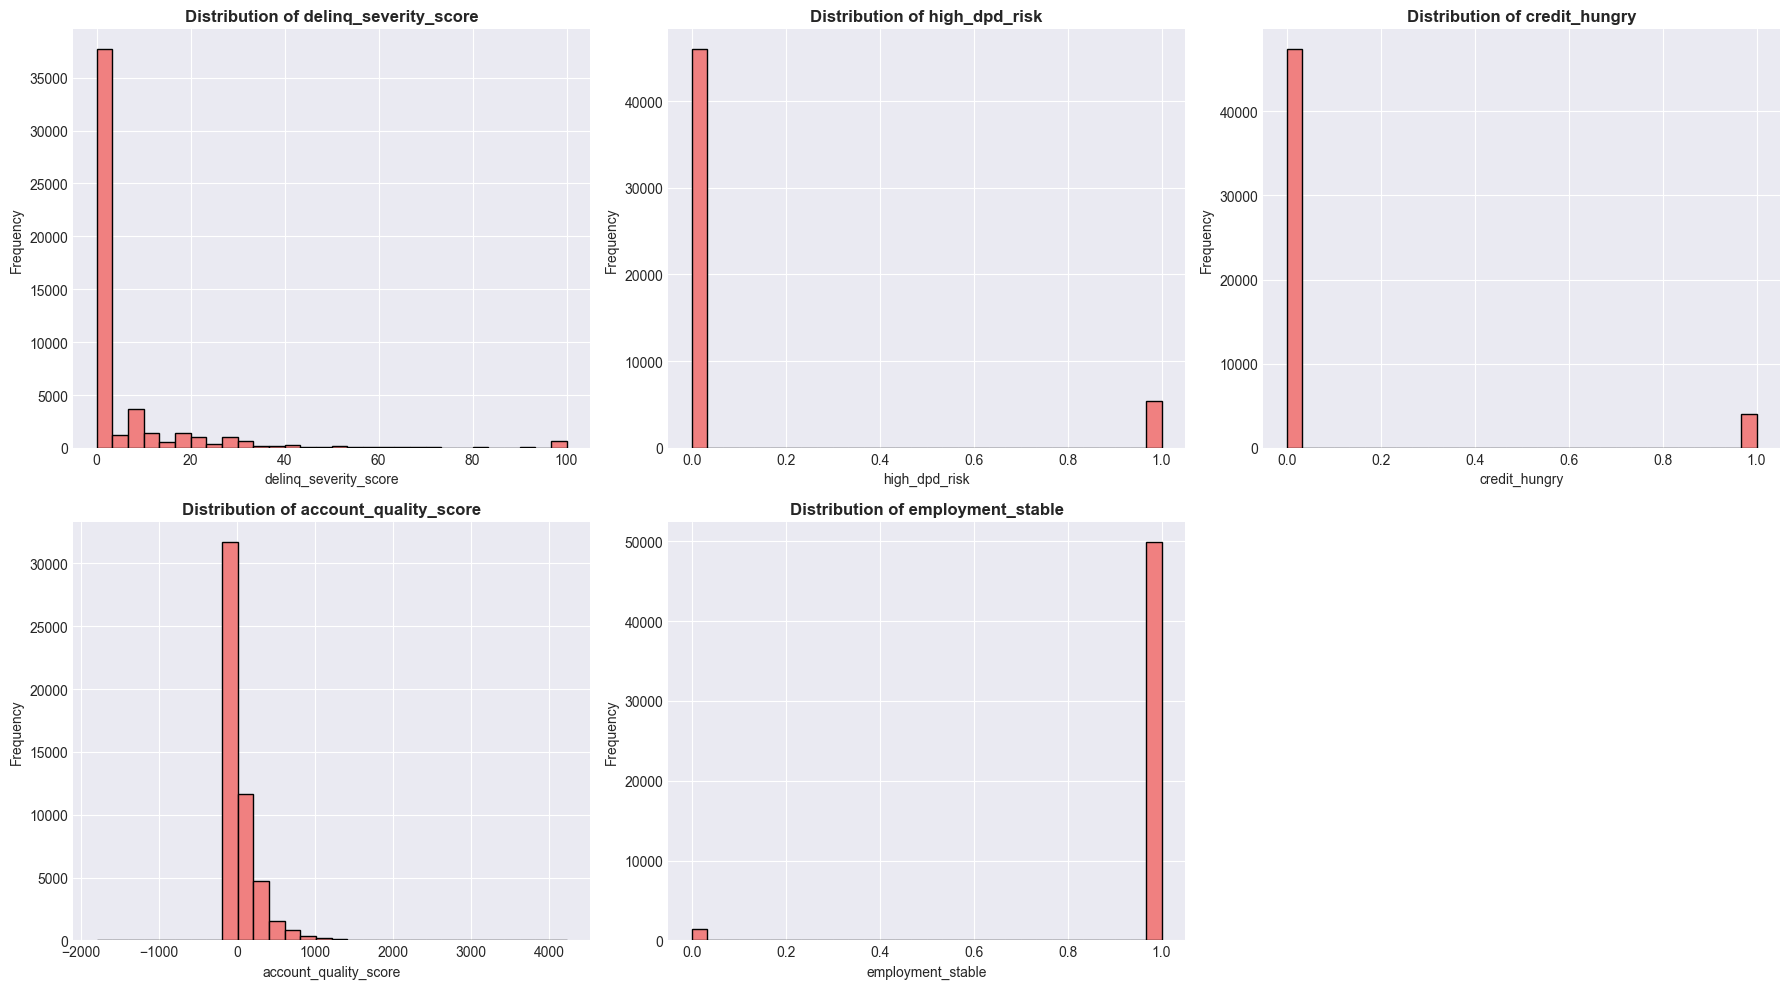

In [13]:
# Visualize engineered features
engineered_features = [
    'delinq_severity_score', 'high_dpd_risk', 'credit_hungry', 
    'account_quality_score', 'employment_stable'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(engineered_features):
    if col in df_clean.columns:
        df_clean[col].hist(bins=30, ax=axes[i], color='lightcoral', edgecolor='black')
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('Frequency', fontsize=10)

# Hide extra subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

---
## 6. Feature Selection

In [14]:
# Prepare data for feature selection
print("🎯 Preparing data for feature selection...\n")

# Separate target
X = df_clean.drop('Approved_Flag', axis=1)
y = df_clean['Approved_Flag']

# Encode categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f"✅ Encoded {len(categorical_cols)} categorical columns")
print(f"✅ Total features: {len(X.columns)}")
print(f"✅ Target classes: {y.unique()}")

🎯 Preparing data for feature selection...

✅ Encoded 5 categorical columns
✅ Total features: 70
✅ Target classes: ['P2' 'P1' 'P3' 'P4']


📊 Method 1: Correlation Analysis

Top 20 Features by Correlation with Target:
 1. Credit_Score                             0.8355
 2. credit_hungry                            0.4581
 3. pct_PL_enq_L6m_of_ever                   0.4039
 4. pct_PL_enq_L6m_of_L12m                   0.3956
 5. num_std_12mts                            0.3186
 6. num_std                                  0.3138
 7. account_quality_score                    0.3107
 8. num_std_6mts                             0.3004
 9. time_since_recent_deliquency             0.2194
10. time_since_first_deliquency              0.2194
11. max_delinquency_level                    0.2194
12. AGE                                      0.2146
13. pct_CC_enq_L6m_of_ever                   0.1880
14. pct_CC_enq_L6m_of_L12m                   0.1873
15. last_prod_enq2                           0.1545
16. Time_With_Curr_Empr                      0.1403
17. MARITALSTATUS                            0.1363
18. pct_opened_TLs_L6m_of_L12m        

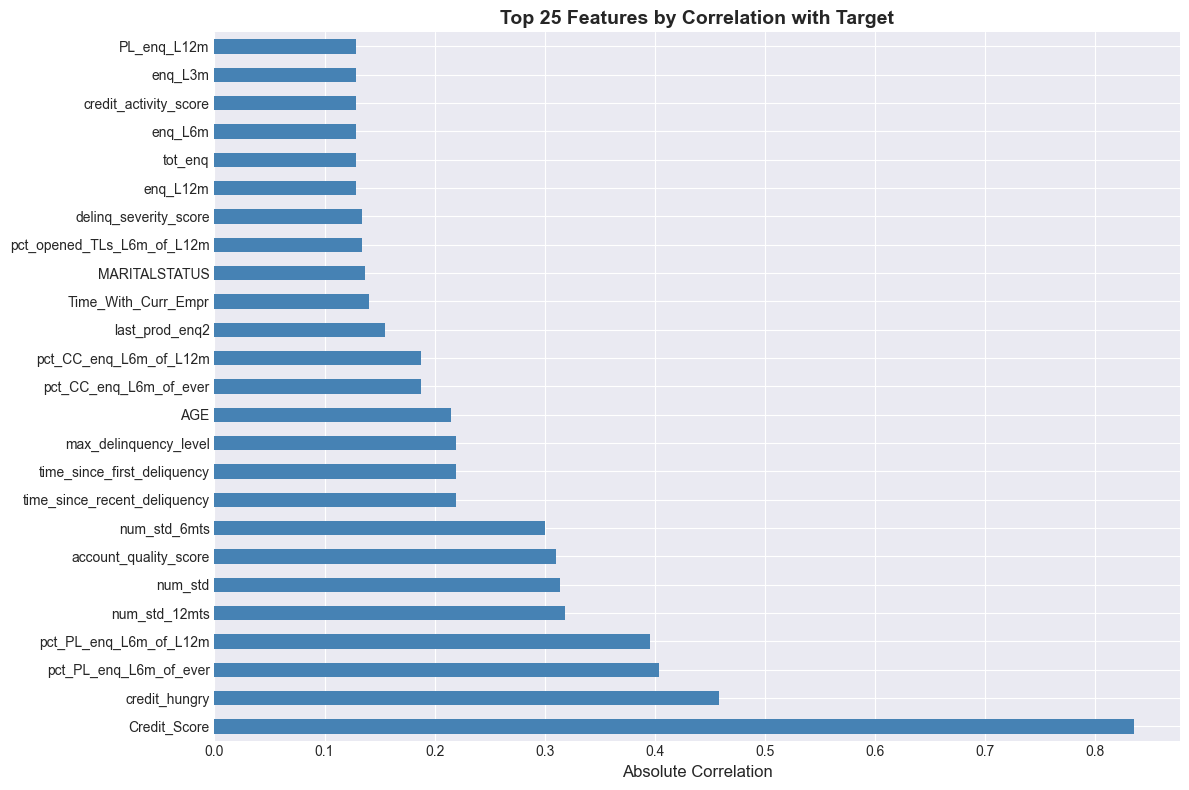

In [15]:
# Method 1: Correlation with target
print("📊 Method 1: Correlation Analysis\n")

# Encode target for correlation
y_encoded = LabelEncoder().fit_transform(y)

# Calculate correlations
correlations = X.corrwith(pd.Series(y_encoded, index=X.index)).abs().sort_values(ascending=False)

print("Top 20 Features by Correlation with Target:")
print("=" * 60)
for i, (feat, corr) in enumerate(correlations.head(20).items(), 1):
    print(f"{i:2d}. {feat:40s} {corr:.4f}")

# Visualize
plt.figure(figsize=(12, 8))
correlations.head(25).plot(kind='barh', color='steelblue')
plt.xlabel('Absolute Correlation', fontsize=12)
plt.title('Top 25 Features by Correlation with Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


📊 Method 2: Mutual Information

Top 20 Features by Mutual Information:
 1. Credit_Score                             1.0578
 2. enq_L3m                                  0.1821
 3. credit_activity_score                    0.1784
 4. enq_L6m                                  0.1521
 5. time_since_recent_enq                    0.1263
 6. enq_L12m                                 0.1252
 7. account_quality_score                    0.0919
 8. credit_hungry                            0.0919
 9. num_std                                  0.0877
10. PL_enq_L6m                               0.0840
11. pct_PL_enq_L6m_of_ever                   0.0824
12. num_std_12mts                            0.0816
13. pct_PL_enq_L6m_of_L12m                   0.0791
14. num_std_6mts                             0.0734
15. tot_enq                                  0.0719
16. PL_enq_L12m                              0.0716
17. pct_of_active_TLs_ever                   0.0526
18. PL_enq                                  

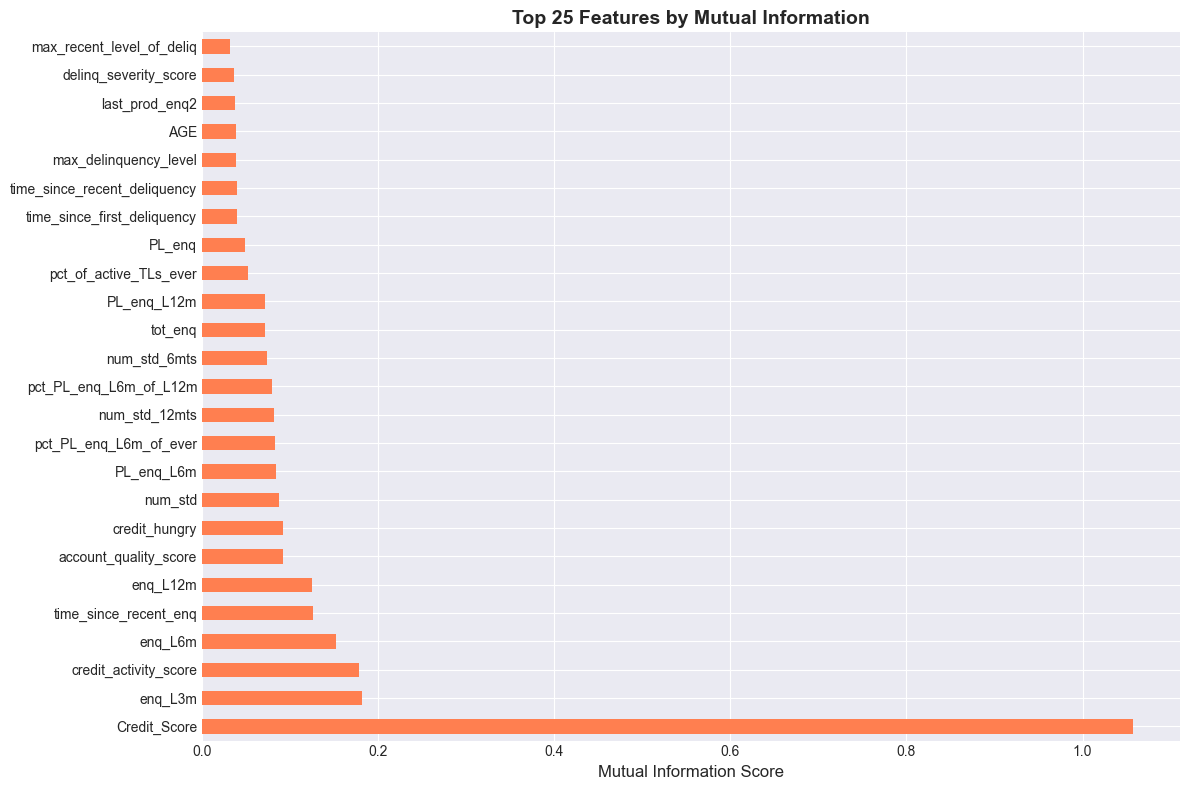

In [16]:
# Method 2: Mutual Information
print("\n📊 Method 2: Mutual Information\n")

mi_scores = mutual_info_classif(X, y_encoded, random_state=42)
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Top 20 Features by Mutual Information:")
print("=" * 60)
for i, (feat, score) in enumerate(mi_scores.head(20).items(), 1):
    print(f"{i:2d}. {feat:40s} {score:.4f}")

# Visualize
plt.figure(figsize=(12, 8))
mi_scores.head(25).plot(kind='barh', color='coral')
plt.xlabel('Mutual Information Score', fontsize=12)
plt.title('Top 25 Features by Mutual Information', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


📊 Method 3: Random Forest Feature Importance

Top 20 Features by Random Forest Importance:
 1. Credit_Score                             0.5721
 2. enq_L3m                                  0.0516
 3. credit_activity_score                    0.0324
 4. num_std                                  0.0309
 5. credit_hungry                            0.0274
 6. account_quality_score                    0.0266
 7. num_std_12mts                            0.0252
 8. enq_L6m                                  0.0224
 9. time_since_recent_enq                    0.0176
10. pct_PL_enq_L6m_of_ever                   0.0176
11. enq_L12m                                 0.0163
12. time_since_recent_deliquency             0.0160
13. num_std_6mts                             0.0141
14. pct_of_active_TLs_ever                   0.0120
15. pct_PL_enq_L6m_of_L12m                   0.0095
16. time_since_first_deliquency              0.0084
17. PL_enq_L6m                               0.0079
18. AGE                 

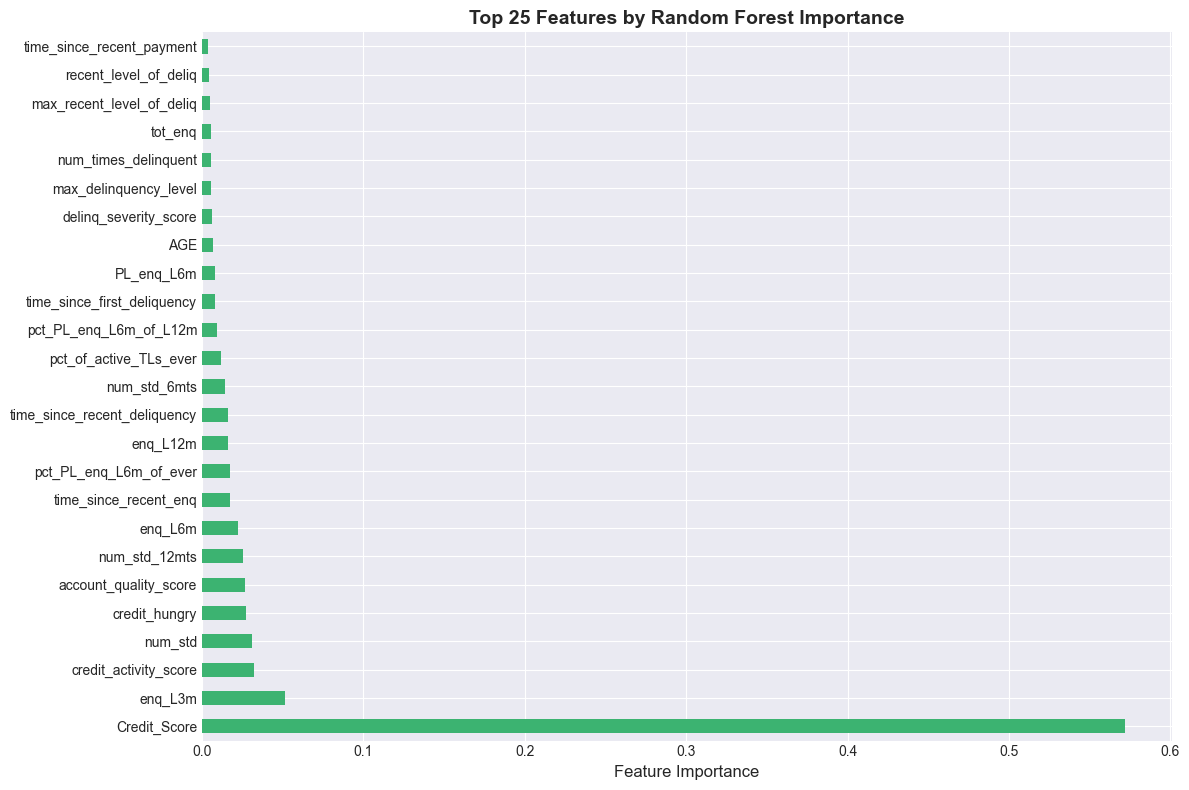

In [17]:
# Method 3: Random Forest Feature Importance (Quick)
print("\n📊 Method 3: Random Forest Feature Importance\n")

# Quick RF for feature importance
rf_quick = RandomForestClassifier(
    n_estimators=50, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1
)

rf_quick.fit(X, y_encoded)

rf_importances = pd.Series(rf_quick.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 20 Features by Random Forest Importance:")
print("=" * 60)
for i, (feat, imp) in enumerate(rf_importances.head(20).items(), 1):
    print(f"{i:2d}. {feat:40s} {imp:.4f}")

# Visualize
plt.figure(figsize=(12, 8))
rf_importances.head(25).plot(kind='barh', color='mediumseagreen')
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 25 Features by Random Forest Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


🎯 Combined Feature Selection (Top 40 Features)

Top 40 Features by Combined Score:
 1. Credit_Score                             Combined: 1.0000
 2. credit_hungry                            Combined: 0.2275
 3. pct_PL_enq_L6m_of_ever                   Combined: 0.1972
 4. pct_PL_enq_L6m_of_L12m                   Combined: 0.1881
 5. num_std                                  Combined: 0.1706
 6. account_quality_score                    Combined: 0.1682
 7. num_std_12mts                            Combined: 0.1672
 8. num_std_6mts                             Combined: 0.1509
 9. enq_L3m                                  Combined: 0.1386
10. credit_activity_score                    Combined: 0.1262
11. enq_L6m                                  Combined: 0.1121
12. time_since_recent_deliquency             Combined: 0.1091
13. time_since_first_deliquency              Combined: 0.1047
14. max_delinquency_level                    Combined: 0.1028
15. AGE                                      Com

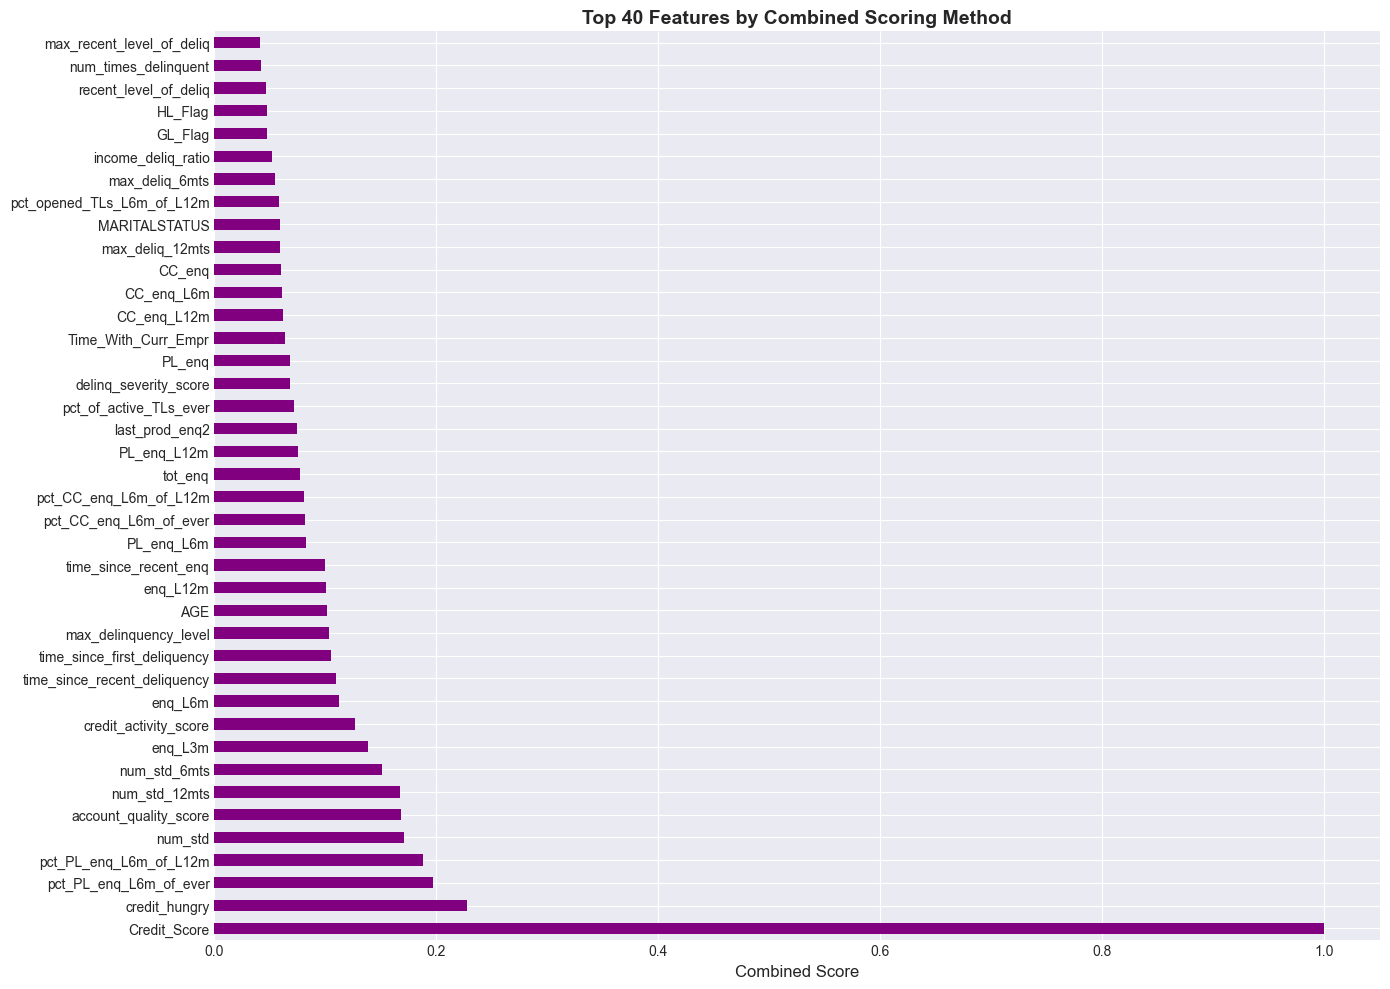

In [18]:
# Combine all three methods
print("\n🎯 Combined Feature Selection (Top 40 Features)\n")

# Normalize scores to 0-1
corr_norm = (correlations - correlations.min()) / (correlations.max() - correlations.min())
mi_norm = (mi_scores - mi_scores.min()) / (mi_scores.max() - mi_scores.min())
rf_norm = (rf_importances - rf_importances.min()) / (rf_importances.max() - rf_importances.min())

# Combined score (average of all three)
combined_scores = pd.DataFrame({
    'correlation': corr_norm,
    'mutual_info': mi_norm,
    'rf_importance': rf_norm
})

combined_scores['combined_score'] = combined_scores.mean(axis=1)
combined_scores = combined_scores.sort_values('combined_score', ascending=False)

print("Top 40 Features by Combined Score:")
print("=" * 80)
for i, (feat, row) in enumerate(combined_scores.head(40).iterrows(), 1):
    print(f"{i:2d}. {feat:40s} Combined: {row['combined_score']:.4f}")

# Select top 40 features
selected_features = combined_scores.head(40).index.tolist()

print(f"\n✅ Selected {len(selected_features)} features for modeling")

# Visualize combined scores
plt.figure(figsize=(14, 10))
combined_scores.head(40)['combined_score'].plot(kind='barh', color='purple')
plt.xlabel('Combined Score', fontsize=12)
plt.title('Top 40 Features by Combined Scoring Method', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Model Training

In [19]:
# Prepare final training data
print("📊 Preparing final training data...\n")

X_selected = X[selected_features]
y_final = y

# Encode target
target_le = LabelEncoder()
y_encoded_final = target_le.fit_transform(y_final)

print(f"✅ Features: {X_selected.shape[1]}")
print(f"✅ Samples: {len(X_selected):,}")
print(f"✅ Target classes: {target_le.classes_}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_encoded_final,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded_final
)

print(f"\n✅ Training set: {len(X_train):,} samples")
print(f"✅ Test set: {len(X_test):,} samples")

# Check class distribution
print("\n📊 Training set distribution:")
for i, cls in enumerate(target_le.classes_):
    count = np.sum(y_train == i)
    pct = (count / len(y_train)) * 100
    print(f"   {cls}: {count:,} ({pct:.1f}%)")

📊 Preparing final training data...

✅ Features: 40
✅ Samples: 51,336
✅ Target classes: ['P1' 'P2' 'P3' 'P4']

✅ Training set: 41,068 samples
✅ Test set: 10,268 samples

📊 Training set distribution:
   P1: 4,642 (11.3%)
   P2: 25,759 (62.7%)
   P3: 5,961 (14.5%)
   P4: 4,706 (11.5%)


In [20]:
# Train Random Forest Model
print("🤖 Training Random Forest Classifier...\n")
print("This may take 2-3 minutes...\n")

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced',  # Handle class imbalance
    n_jobs=-1,
    verbose=1
)

# Train
model.fit(X_train, y_train)

print("\n✅ Model training completed!")

🤖 Training Random Forest Classifier...

This may take 2-3 minutes...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    1.4s



✅ Model training completed!


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    1.6s finished


---
## 8. Model Evaluation

In [21]:
# Training accuracy
train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

print(f"📊 Training Accuracy: {train_acc * 100:.2f}%")

# Test accuracy
test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print(f"📊 Test Accuracy: {test_acc * 100:.2f}%")

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s


📊 Training Accuracy: 99.77%
📊 Test Accuracy: 98.79%


[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished


In [22]:
# Cross-validation
print("\n🔄 Running 5-Fold Cross-Validation...")
print("This may take 1-2 minutes...\n")

cv_scores = cross_val_score(model, X_train, y_train, cv=5, n_jobs=-1)

print(f"✅ CV Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")
print(f"\nFold scores: {[f'{s*100:.2f}%' for s in cv_scores]}")


🔄 Running 5-Fold Cross-Validation...
This may take 1-2 minutes...

✅ CV Accuracy: 98.68% (+/- 0.13%)

Fold scores: ['98.73%', '98.55%', '98.89%', '98.71%', '98.53%']


In [23]:
# Classification Report
print("\n📋 Classification Report (Test Set):")
print("=" * 80)
print(classification_report(
    y_test, test_pred,
    target_names=target_le.classes_,
    digits=3
))


📋 Classification Report (Test Set):
              precision    recall  f1-score   support

          P1      0.946     0.974     0.960      1161
          P2      0.992     1.000     0.996      6440
          P3      0.994     0.937     0.964      1491
          P4      0.999     1.000     1.000      1176

    accuracy                          0.988     10268
   macro avg      0.983     0.978     0.980     10268
weighted avg      0.988     0.988     0.988     10268




📊 Confusion Matrix:
[[1131   21    9    0]
 [   0 6440    0    0]
 [  65   28 1397    1]
 [   0    0    0 1176]]

Rows = Actual, Columns = Predicted
Classes: P1, P2, P3, P4


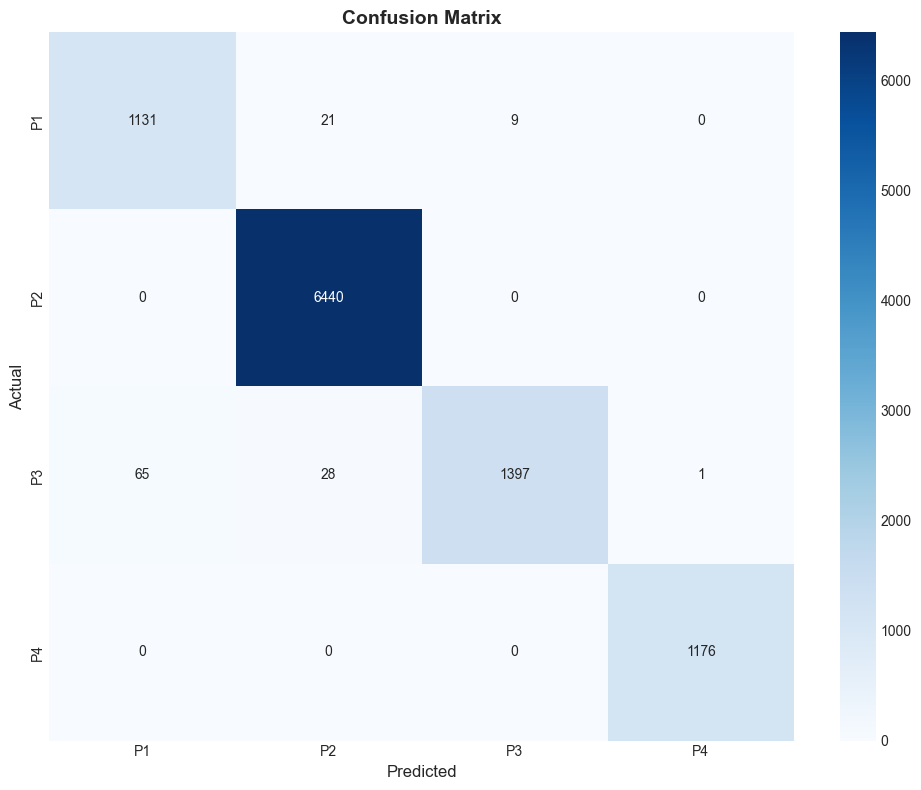


🎯 Per-Class Accuracy:
   P1: 97.42% (1131/1161)
   P2: 100.00% (6440/6440)
   P3: 93.70% (1397/1491)
   P4: 100.00% (1176/1176)


In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, test_pred)

print("\n📊 Confusion Matrix:")
print("=" * 80)
print(cm)
print("\nRows = Actual, Columns = Predicted")
print(f"Classes: {', '.join(target_le.classes_)}")

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=target_le.classes_,
    yticklabels=target_le.classes_
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\n🎯 Per-Class Accuracy:")
for i, cls in enumerate(target_le.classes_):
    class_correct = cm[i, i]
    class_total = cm[i, :].sum()
    class_acc = (class_correct / class_total * 100) if class_total > 0 else 0
    print(f"   {cls}: {class_acc:.2f}% ({class_correct}/{class_total})")

---
## 9. Feature Importance Analysis

🏆 Top 20 Most Important Features (Final Model):
 1. Credit_Score                             0.5704
10. credit_activity_score                    0.0443
 9. enq_L3m                                  0.0376
 5. num_std                                  0.0326
 7. num_std_12mts                            0.0296
 6. account_quality_score                    0.0280
17. time_since_recent_enq                    0.0241
11. enq_L6m                                  0.0235
 2. credit_hungry                            0.0189
24. pct_of_active_TLs_ever                   0.0183
 8. num_std_6mts                             0.0174
12. time_since_recent_deliquency             0.0148
15. AGE                                      0.0125
16. enq_L12m                                 0.0108
 3. pct_PL_enq_L6m_of_ever                   0.0102
13. time_since_first_deliquency              0.0095
 4. pct_PL_enq_L6m_of_L12m                   0.0091
14. max_delinquency_level                    0.0081
21. tot_enq     

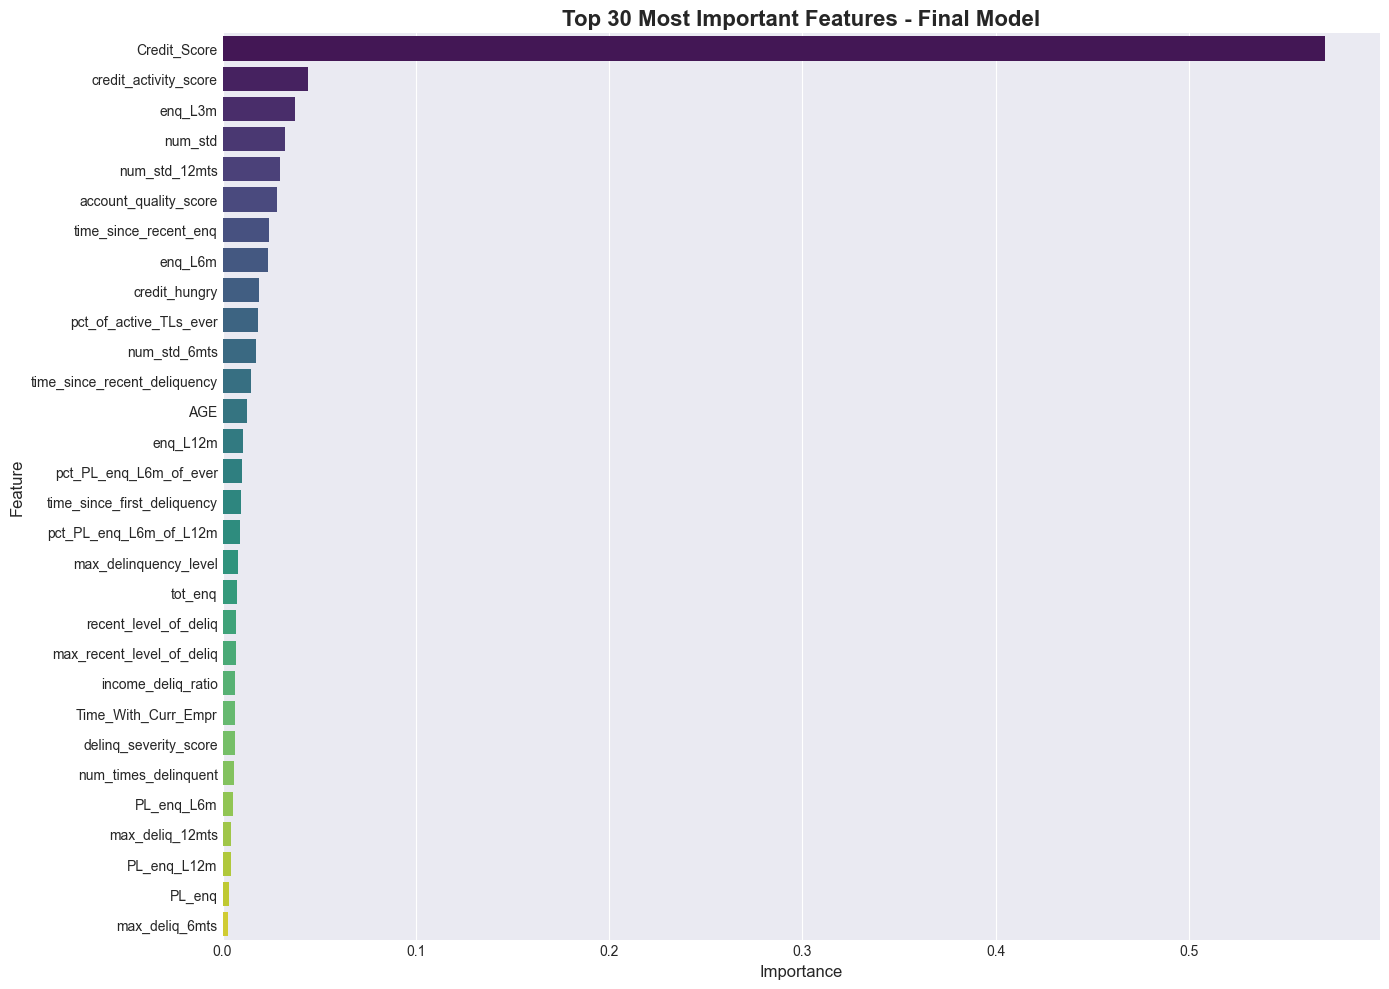


✅ Feature importance plot saved as 'stage2_feature_importance.png'


In [25]:
# Feature importance from final model
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("🏆 Top 20 Most Important Features (Final Model):")
print("=" * 80)
for i, row in feature_importance.head(20).iterrows():
    print(f"{row.name+1:2d}. {row['feature']:40s} {row['importance']:.4f}")

# Visualize
plt.figure(figsize=(14, 10))
sns.barplot(
    data=feature_importance.head(30),
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title('Top 30 Most Important Features - Final Model', fontsize=16, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('stage2_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Feature importance plot saved as 'stage2_feature_importance.png'")

---
## 10. Save Model

In [26]:
# Save model and assets
print("💾 Saving model assets...\n")

model_assets = {
    'model': model,
    'features': selected_features,
    'label_encoder': target_le,
    'categorical_encoders': label_encoders,
    'feature_importance': feature_importance,
    'train_accuracy': train_acc,
    'test_accuracy': test_acc,
    'cv_scores': cv_scores,
    'confusion_matrix': cm,
    'training_date': datetime.now().isoformat(),
    'n_samples': len(df_clean),
    'n_features': len(selected_features),
    'target_classes': target_le.classes_.tolist()
}

# Save
output_path = 'stage2_cibil_model.pkl'
joblib.dump(model_assets, output_path)

import os
file_size = os.path.getsize(output_path) / 1024 / 1024

print(f"✅ Model saved: {output_path}")
print(f"   File size: {file_size:.2f} MB")
print(f"   Features: {len(selected_features)}")
print(f"   Accuracy: {test_acc * 100:.2f}%")
print(f"   Classes: {', '.join(target_le.classes_)}")

💾 Saving model assets...

✅ Model saved: stage2_cibil_model.pkl
   File size: 32.88 MB
   Features: 40
   Accuracy: 98.79%
   Classes: P1, P2, P3, P4


---
## 11. Test Predictions

In [27]:
# Test on random samples
print("🧪 Testing predictions on random samples...\n")

n_samples = 5
sample_indices = np.random.choice(len(X_test), n_samples, replace=False)

for idx in sample_indices:
    sample_X = X_test.iloc[idx:idx+1]
    sample_y_true = y_test[idx]
    sample_y_pred = model.predict(sample_X)[0]
    sample_proba = model.predict_proba(sample_X)[0]
    
    true_label = target_le.inverse_transform([sample_y_true])[0]
    pred_label = target_le.inverse_transform([sample_y_pred])[0]
    
    print(f"Sample {idx}:")
    print(f"   True: {true_label}")
    print(f"   Predicted: {pred_label}")
    print(f"   Confidence: {max(sample_proba) * 100:.1f}%")
    print(f"   Probabilities:")
    for i, prob in enumerate(sample_proba):
        cls = target_le.classes_[i]
        print(f"      {cls}: {prob * 100:.1f}%")
    
    if pred_label == true_label:
        print(f"   ✅ CORRECT\n")
    else:
        print(f"   ❌ WRONG\n")

🧪 Testing predictions on random samples...

Sample 9562:
   True: P2
   Predicted: P2
   Confidence: 97.6%
   Probabilities:
      P1: 0.4%
      P2: 97.6%
      P3: 2.0%
      P4: 0.0%
   ✅ CORRECT

Sample 2226:
   True: P2
   Predicted: P2
   Confidence: 97.9%
   Probabilities:
      P1: 1.6%
      P2: 97.9%
      P3: 0.5%
      P4: 0.0%
   ✅ CORRECT



[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Do

Sample 8845:
   True: P2
   Predicted: P2
   Confidence: 99.4%
   Probabilities:
      P1: 0.2%
      P2: 99.4%
      P3: 0.4%
      P4: 0.0%
   ✅ CORRECT

Sample 5840:
   True: P2
   Predicted: P2
   Confidence: 98.9%
   Probabilities:
      P1: 0.9%
      P2: 98.9%
      P3: 0.2%
      P4: 0.0%
   ✅ CORRECT

Sample 3429:
   True: P1
   Predicted: P1
   Confidence: 96.4%
   Probabilities:
      P1: 96.4%
      P2: 0.6%
      P3: 3.0%
      P4: 0.0%
   ✅ CORRECT



[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished


---
## 📊 Final Summary

In [29]:
print("=" * 80)
print("STAGE 2 MODEL TRAINING COMPLETE!")
print("=" * 80)

print(f"\n📊 Final Metrics:")
print(f"   Training Accuracy:    {train_acc * 100:.2f}%")
print(f"   Test Accuracy:        {test_acc * 100:.2f}%")
print(f"   Cross-Validation:     {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")

print(f"\n📦 Model Details:")
print(f"   Features Selected:    {len(selected_features)}")
print(f"   Total Samples:        {len(df_clean):,}")
print(f"   Training Samples:     {len(X_train):,}")
print(f"   Test Samples:         {len(X_test):,}")
print(f"   Target Classes:       {', '.join(target_le.classes_)}")

print(f"\n💾 Saved Assets:")
print(f"   Model File:           {output_path} ({file_size:.2f} MB)")
print(f"   Feature Plot:         stage2_feature_importance.png")

print(f"\n🎯 Next Steps:")
print(f"   1. Integrate into test.py using two_stage_integration.py")
print(f"   2. Test with real customer data")
print(f"   3. Monitor performance in production")

print(f"\n⏱️ Training completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

STAGE 2 MODEL TRAINING COMPLETE!

📊 Final Metrics:
   Training Accuracy:    99.77%
   Test Accuracy:        98.79%
   Cross-Validation:     98.68% (+/- 0.13%)

📦 Model Details:
   Features Selected:    40
   Total Samples:        51,336
   Training Samples:     41,068
   Test Samples:         10,268
   Target Classes:       P1, P2, P3, P4

💾 Saved Assets:
   Model File:           stage2_cibil_model.pkl (32.88 MB)
   Feature Plot:         stage2_feature_importance.png

🎯 Next Steps:
   1. Integrate into test.py using two_stage_integration.py
   2. Test with real customer data
   3. Monitor performance in production

⏱️ Training completed: 2026-02-11 14:35:22
